# Closed-form RNNs for discrete $SE(3)$

This notebook constructs a QuadraticRNN for

$$G=\mathbb{Z}_n^3\rtimes O,$$

where $O$ is the 24-element group of orientation-preserving cubic rotations. A vector $x\in\mathbb{R}^{|G|}$ is equivalently a scalar signal $x:G\to\mathbb{R}$, and the network realizes the regular left action

$$(g\cdot x)[h]=x[g^{-1}h].$$

We make two distinct claims:

1. **Exact small case:** all irreps at $n=2$ reproduce translation, rotation, and mixed composition to floating-point precision.
2. **Truncated spatial case:** selected Fourier blocks at $n=3$ trade exact reconstruction for a much smaller hidden state.

No weights are learned.

In [1]:
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

project_root = next(
    parent
    for parent in (Path.cwd(), *Path.cwd().parents)
    if (parent / "src").is_dir()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.discrete_se3_geometry import (
    decode_pose,
    gaussian_landmark,
    orientation_energy,
    orientation_marginal,
    peaked_orientation_weights,
    periodic_distance_squared,
    plot_orientation_marginal,
    plot_orthogonal_slices,
    plot_pose_trajectory,
    plot_volume_scatter,
    rotation_error,
    spatial_energy,
    spatial_marginal,
    transformed_pose,
)
from src.finite_group_rnn import (
    build_finite_group_rnn,
    hidden_width,
    probe_hidden_states as hidden_tuning_over_group,
    random_invertible_encoding,
    rollout,
    select_irreps_by_power,
)
from src.groups import DiscreteSE3Group
from src.neural_manifold import (
    analyze_module_orbits,
    build_module_orbits,
    coordinate_colors,
    fixed_point_embedding,
    plot_manifold_analysis,
)

np.set_printoptions(precision=3, suppress=True)

## 1. Group and representation structure

Write an element as $g=(t,r)$, with $t\in\mathbb{Z}_n^3$ and $r\in O$. If $R_r$ is the signed permutation matrix for rotation $r$, then

$$(t_1,r_1)(t_2,r_2)=(t_1+R_{r_1}t_2,\ r_1r_2).$$

Elements are flattened with rotation as the most significant coordinate:

$$\operatorname{idx}(x,y,z,r)=rn^3+xn^2+yn+z.$$

Irreps are constructed by the little-group method: cubic rotations act on translation frequencies $k\in\mathbb{Z}_n^3$, and stabilizer irreps are induced to the full semidirect product. The implementation checks $\sum_\rho d_\rho^2=|G|$.

In [2]:
G_exact = DiscreteSE3Group(n=2)
irreps_exact = G_exact.irreps()
dimension_counts = Counter(irrep.dim for irrep in irreps_exact)
exact_width = sum(hidden_width(irrep) for irrep in irreps_exact)

print(f"|G| = {G_exact.order}")
print(f"number of irreps = {len(irreps_exact)}")
print("irrep dimension counts =", dict(sorted(dimension_counts.items())))
print("Peter–Weyl sum =", sum(irrep.dim**2 for irrep in irreps_exact))
print("all-irrep hidden width =", exact_width)
assert sum(irrep.dim**2 for irrep in irreps_exact) == G_exact.order

|G| = 192
number of irreps = 20
irrep dimension counts = {1: 4, 2: 2, 3: 12, 6: 2}
Peter–Weyl sum = 192
all-irrep hidden width = 9312


## 2. Closed-form QuadraticRNN

For each irrep,

$$\widehat{x}(\rho)=\sum_{g\in G}x(g)\rho(g)^\dagger.$$

Let $\phi(z)=\operatorname{ReLU}(z)^2$. For relative drives $g_1,\ldots,g_T$,

$$h_1=\phi(W_{\rm in}x_{\rm allo}+W_{\rm drive}(g_1\cdot x_{\rm ego})),$$

$$h_t=\phi(W_{\rm mix}h_{t-1}+W_{\rm drive}(g_t\cdot x_{\rm ego})),\qquad y_t=W_{\rm out}h_t.$$

The trace-feature construction contributes $12d_\rho^3$ hidden units per irrep. We apply

$$W_{\rm mix}h=W_{\rm in}(W_{\rm out}h)$$

without materializing a hidden-by-hidden matrix. When every irrep is included and every $\widehat{x}_{\rm ego}(\rho)$ is invertible, $y_t=(g_t\cdots g_1)\cdot x_{\rm allo}$ exactly, up to floating-point error.

In [3]:
rng = np.random.default_rng(7)
x_allo_exact = rng.normal(size=G_exact.order)
x_ego_exact = random_invertible_encoding(G_exact, irreps_exact, seed=11)

params_exact = build_finite_group_rnn(
    G_exact,
    x_ego_exact,
    irrep_selection="all",
    materialize_mix=False,
)

print("hidden width:", params_exact.hidden_dim)
print("W_in shape:", params_exact.W_in.shape)
print("W_out shape:", params_exact.W_out.shape)
print("W_mix materialized:", params_exact.W_mix is not None)
assert params_exact.hidden_dim == exact_width

hidden width: 9312
W_in shape: (9312, 192)
W_out shape: (192, 9312)
W_mix materialized: False


## 3. Exactness checks

The complete $n=2$ model is tested on translations, rotations about different axes, and mixed noncommuting sequences. All tokens are relative drives; the initial signal is supplied separately. This checks both the representation formula and the multiplication order $g_T\cdots g_1$.

In [4]:
def rotation_index(group, matrix):
    matrix = np.asarray(matrix)
    return next(
        rotation
        for rotation in range(group.num_rotations)
        if np.array_equal(group.rotation_matrix(rotation), matrix)
    )


rotation_x_90 = rotation_index(
    G_exact,
    [[1, 0, 0], [0, 0, -1], [0, 1, 0]],
)
rotation_z_90 = rotation_index(
    G_exact,
    [[0, -1, 0], [1, 0, 0], [0, 0, 1]],
)

exact_sequences = {
    "translation": [G_exact.encode(1, 0, 0, 0)],
    "rotation": [G_exact.encode(0, 0, 0, rotation_x_90)],
    "mixed": [
        G_exact.encode(1, 0, 0, 0),
        G_exact.encode(0, 0, 0, rotation_z_90),
        G_exact.encode(0, 1, 0, 0),
        G_exact.encode(0, 0, 0, rotation_x_90),
    ],
}

for name, sequence in exact_sequences.items():
    result = rollout(params_exact, x_allo_exact, sequence)
    error = np.max(np.abs(result["predicted_outputs"] - result["true_outputs"]))
    print(f"{name:12s} max absolute error = {error:.3e}")
    assert error < 1e-10

translation  max absolute error = 2.731e-14
rotation     max absolute error = 3.608e-14
mixed        max absolute error = 5.690e-14


## 4. Truncated spatial and orientation experiment

At $n=3$, the full group has 648 elements and the all-irrep construction would require 71,040 hidden units. We instead select at most six irreps under a 10,000-unit budget using `irrep_selection="power"` with `power_ranking="power_per_hidden"`: the code ranks irreps by allocentric Fourier power divided by their hidden-width cost, then keeps the highest-ranked irreps that fit the budget, with the trivial/DC irrep always included.

The theorem's width contribution is $4q_\rho d_\rho^3$; with `q_rho=3`, each retained irrep contributes $12d_\rho^3$ hidden units. This cubic dependence on irrep dimension is why the SE(3) notebook ranks by power per hidden unit instead of raw power alone.

The allocentric signal is an off-center anisotropic Gaussian with a profile peaked at the identity orientation. Both choices matter: an isotropic signal copied uniformly over rotations cannot diagnose orientation errors.

### Visualization convention

There is no single two-dimensional analogue of the SE(2) hexagon map. We use the simplest views that preserve the relevant structure:

- three orthogonal slices summarize a spatial volume;
- a 24-bin bar plot summarizes the discrete orientation coordinate;
- random signed encodings are shown through root-mean-square **energy**, rather than a signed sum that can cancel;
- trajectories are plotted in the wrapped $n\times n\times n$ cube, with line segments broken at periodic boundaries;
- hidden-unit spatial tuning is shown as a colored 3D lattice, accompanied by a neuron-by-orientation heatmap.

These are diagnostic projections, not lossless visualizations of the full four-dimensional signal on $\mathbb Z_n^3\times O$.

In [5]:
G = DiscreteSE3Group(n=3)
initial_pose = (1, 0, 2, 0)
x_allo = gaussian_landmark(
    G,
    center=initial_pose[:3],
    sigma=(0.4, 0.7, 1.0),
    orientation_weights=peaked_orientation_weights(G, rotation=initial_pose[3], floor=0.05),
)

all_irreps = G.irreps()
selected_irreps, selected_indices = select_irreps_by_power(
    all_irreps,
    x_allo,
    num_irreps=6,
    max_hidden_width=10_000,
    ranking="power_per_hidden",
)
x_ego = random_invertible_encoding(G, selected_irreps, seed=19)
params = build_finite_group_rnn(
    G,
    x_ego,
    irreps=all_irreps,
    x_allo=x_allo,
    irrep_selection="power",
    num_irreps=6,
    max_hidden_width=10_000,
    power_ranking="power_per_hidden",
    materialize_mix=False,
)

print(f"|G|={G.order}; all irreps={len(all_irreps)}")
print("selected global indices:", params.selected_irrep_indices)
print("selected dimensions:", [irrep.dim for irrep in params.irreps])
print("hidden width:", params.hidden_dim)

|G|=648; all irreps=14
selected global indices: [0, 1, 2, 3, 4, 6]
selected dimensions: [1, 1, 2, 3, 3, 6]
hidden width: 3360


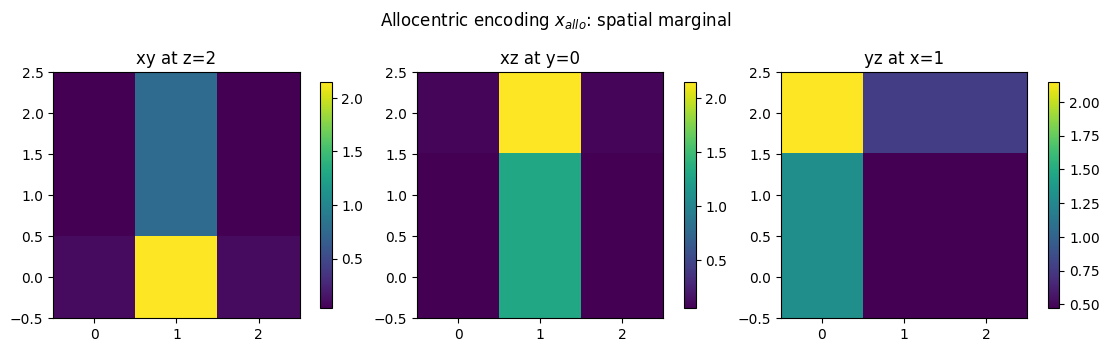

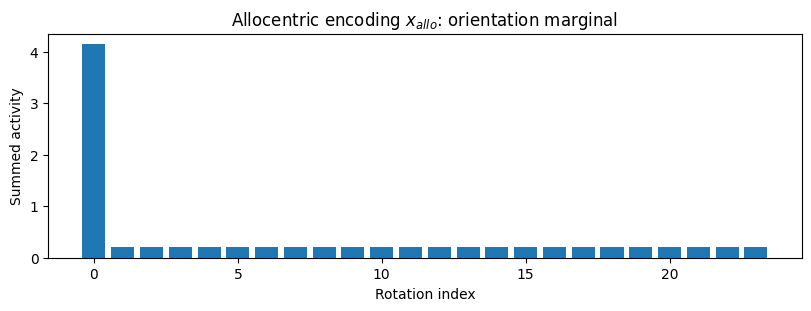

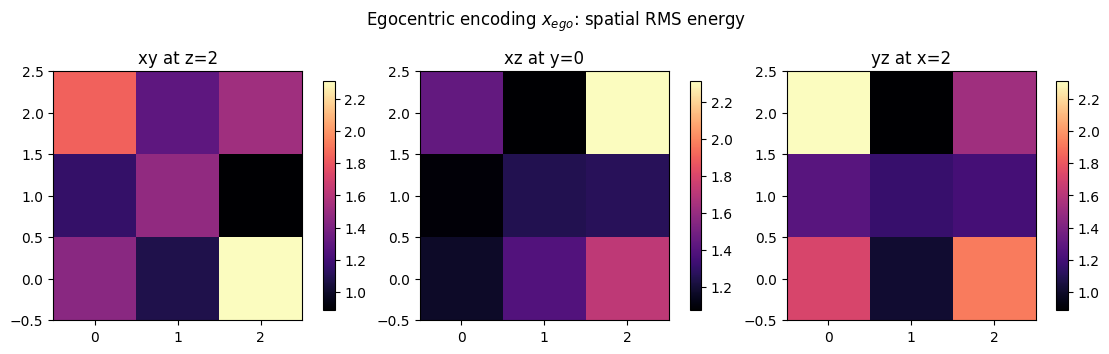

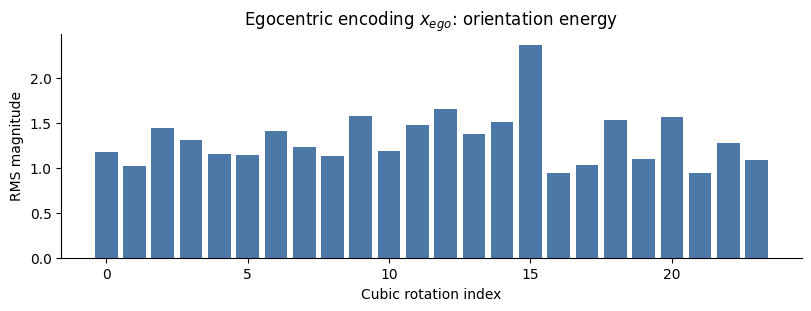

In [6]:
# Allocentric encoding: signed marginals are meaningful because this signal is
# nonnegative and has an intentionally peaked orientation profile.
spatial = spatial_marginal(G, x_allo)
plot_orthogonal_slices(
    spatial,
    center=initial_pose[:3],
    title="Allocentric encoding $x_{allo}$: spatial marginal",
)
plt.show()

plot_orientation_marginal(
    G,
    x_allo,
    title="Allocentric encoding $x_{allo}$: orientation marginal",
)
plt.show()

# Egocentric encoding: use RMS magnitude so positive and negative random entries
# do not disappear through cancellation.
x_ego_spatial_energy = spatial_energy(G, x_ego)
plot_orthogonal_slices(
    x_ego_spatial_energy,
    title="Egocentric encoding $x_{ego}$: spatial RMS energy",
    cmap="magma",
)
plt.show()

figure, ax = plt.subplots(figsize=(8, 3), constrained_layout=True)
ax.bar(np.arange(G.num_rotations), orientation_energy(G, x_ego), color="#4C78A8")
ax.set(
    xlabel="Cubic rotation index",
    ylabel="RMS magnitude",
    title="Egocentric encoding $x_{ego}$: orientation energy",
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

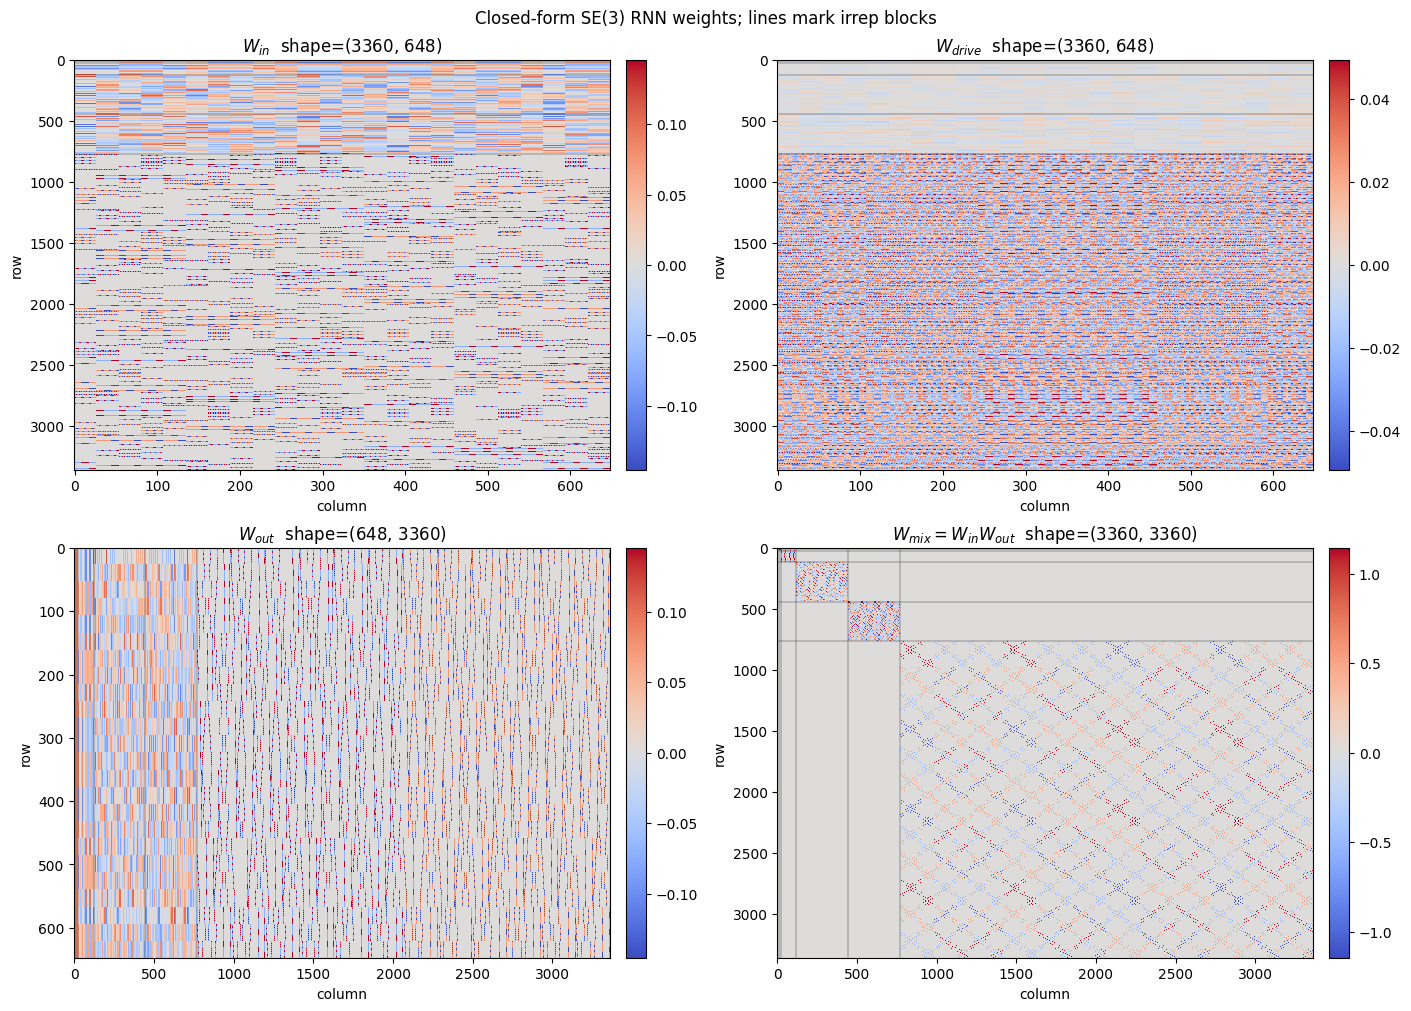

In [7]:
# Closed-form weight operators for the truncated spatial model. W_mix remains
# factored during recurrence and is materialized only for this diagnostic.
W_mix_for_plot = params.W_in @ params.W_out
weight_matrices = {
    r"$W_{in}$": params.W_in,
    r"$W_{drive}$": params.W_drive,
    r"$W_{out}$": params.W_out,
    r"$W_{mix}=W_{in}W_{out}$": W_mix_for_plot,
}
metadata_irreps = np.asarray([item["irrep_index"] for item in params.metadata])
block_boundaries = np.flatnonzero(np.diff(metadata_irreps)) + 1

figure, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
for panel, (ax, (name, matrix)) in enumerate(
    zip(axes.ravel(), weight_matrices.items())
):
    scale = np.percentile(np.abs(matrix), 99)
    image = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="nearest",
        cmap="coolwarm",
        vmin=-scale,
        vmax=scale,
    )
    if panel in (0, 1, 3):
        for boundary in block_boundaries:
            ax.axhline(boundary - 0.5, color="black", linewidth=0.35, alpha=0.7)
    if panel in (2, 3):
        for boundary in block_boundaries:
            ax.axvline(boundary - 0.5, color="black", linewidth=0.35, alpha=0.7)
    ax.set_title(f"{name}  shape={matrix.shape}")
    ax.set_xlabel("column")
    ax.set_ylabel("row")
    figure.colorbar(image, ax=ax, fraction=0.046, pad=0.03)
figure.suptitle("Closed-form SE(3) RNN weights; lines mark irrep blocks")
plt.show()

del W_mix_for_plot

## 5. Translation, rotation, and mixed rollouts

We report three distinct errors:

- relative $\ell_2$ error of the complete group signal;
- periodic Euclidean error of the decoded spatial center;
- geodesic angle between decoded and target cubic rotations.

Separating them reveals whether truncation preserves pose even when signal shape or amplitude is imperfect.

In [8]:
def summarize_rollout(name, sequence):
    result = rollout(params, x_allo, sequence)
    signal_errors = np.linalg.norm(
        result["predicted_outputs"] - result["true_outputs"], axis=1
    ) / np.linalg.norm(result["true_outputs"], axis=1)

    predicted_poses = []
    target_poses = []
    position_errors = []
    orientation_errors = []
    for predicted, state in zip(
        result["predicted_outputs"], result["cumulative_states"]
    ):
        predicted_pose = decode_pose(G, predicted)
        target_pose = transformed_pose(G, int(state), initial_pose)
        predicted_poses.append(predicted_pose)
        target_poses.append(target_pose)
        position_errors.append(
            np.sqrt(periodic_distance_squared(G.n, predicted_pose[:3], target_pose[:3]))
        )
        orientation_errors.append(
            rotation_error(G, predicted_pose[3], target_pose[3])
        )

    print(
        f"{name:16s} final signal={signal_errors[-1]:.3e}; "
        f"max position={max(position_errors):.3f}; "
        f"max rotation={np.degrees(max(orientation_errors)):.1f}°"
    )
    return {
        "rollout": result,
        "signal_errors": np.asarray(signal_errors),
        "position_errors": np.asarray(position_errors),
        "orientation_errors": np.asarray(orientation_errors),
        "predicted_poses": np.asarray(predicted_poses),
        "target_poses": np.asarray(target_poses),
    }


rotation_x_90 = rotation_index(
    G,
    [[1, 0, 0], [0, 0, -1], [0, 1, 0]],
)
rotation_z_90 = rotation_index(
    G,
    [[0, -1, 0], [1, 0, 0], [0, 0, 1]],
)

sequences = {
    "translation-only": [G.encode(1, 0, 0, 0)] * 4,
    "rotation-only": [G.encode(0, 0, 0, rotation_z_90)] * 4,
    "mixed": [
        G.encode(1, 0, 0, 0),
        G.encode(0, 0, 0, rotation_z_90),
        G.encode(0, 1, 0, 0),
        G.encode(0, 0, 0, rotation_x_90),
        G.encode(0, 0, 1, 0),
    ],
}
results = {name: summarize_rollout(name, sequence) for name, sequence in sequences.items()}

translation-only final signal=7.169e-01; max position=0.000; max rotation=0.0°
rotation-only    final signal=7.169e-01; max position=0.000; max rotation=0.0°
mixed            final signal=7.169e-01; max position=0.000; max rotation=0.0°


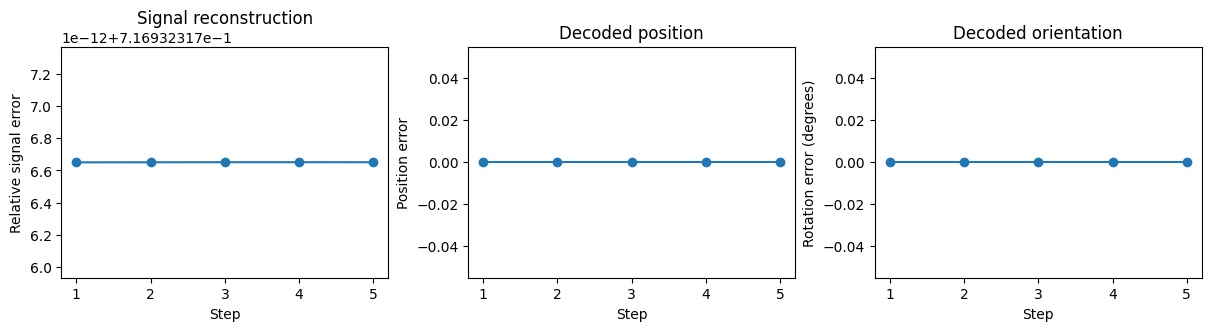

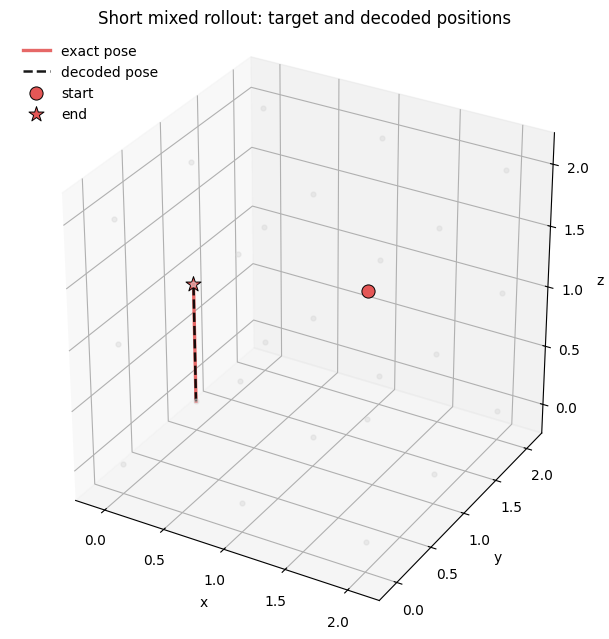

In [9]:
mixed = results["mixed"]
steps = np.arange(1, len(mixed["signal_errors"]) + 1)

figure, axes = plt.subplots(1, 3, figsize=(12, 3.2), constrained_layout=True)
axes[0].plot(steps, mixed["signal_errors"], marker="o")
axes[0].set(xlabel="Step", ylabel="Relative signal error", title="Signal reconstruction")
axes[1].plot(steps, mixed["position_errors"], marker="o")
axes[1].set(xlabel="Step", ylabel="Position error", title="Decoded position")
axes[2].plot(steps, np.degrees(mixed["orientation_errors"]), marker="o")
axes[2].set(xlabel="Step", ylabel="Rotation error (degrees)", title="Decoded orientation")
plt.show()

plot_pose_trajectory(
    G,
    mixed["target_poses"][:, :3],
    mixed["predicted_poses"][:, :3],
    title="Short mixed rollout: target and decoded positions",
)
plt.show()

## 6. Long mixed-motion rollout

A 120-step sequence tests recurrent stability beyond the short algebraic checks. The motion generator uses persistent translations along the six Cartesian directions, occasional stays, and occasional $90^\circ$ cubic rotations. Because $n=3$ is intentionally small, trajectories wrap frequently; the 3D plot therefore breaks line segments at periodic boundaries instead of drawing misleading chords across the cube.

The trajectory plot shows only the spatial component. Orientation is evaluated separately through the geodesic rotation error, since a rotation index is a categorical label rather than a meaningful Euclidean coordinate.

long mixed       final signal=7.169e-01; max position=0.000; max rotation=0.0°
Long-sequence tracking summary
------------------------------
max output error:           1.0923414421755182
mean output error:          1.0923414421755173
max position error:         0.0
mean position error:        0.0
max rotation error (deg):   0.0
mean rotation error (deg):  0.0


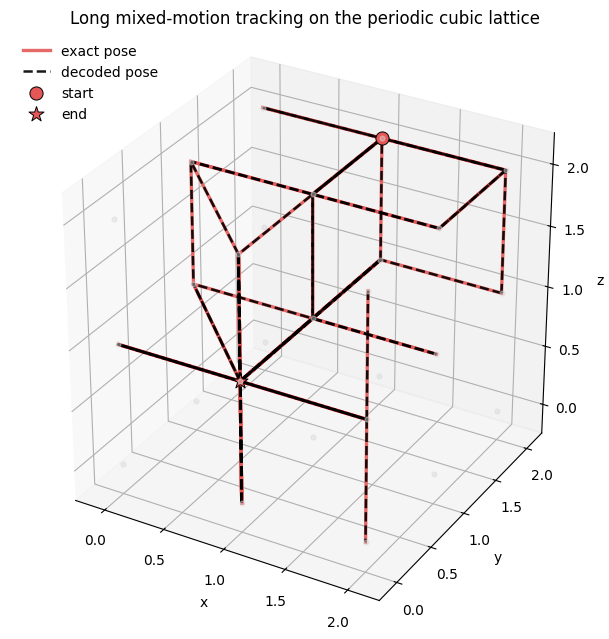

In [10]:
rng_long = np.random.default_rng(31)
translation_steps = np.asarray(
    [(1, 0, 0), (-1, 0, 0), (0, 1, 0), (0, -1, 0), (0, 0, 1), (0, 0, -1)]
)
num_long_steps = 120
long_sequence = []
direction_index = 0
for _ in range(num_long_steps):
    draw = rng_long.random()
    if draw < 0.05:
        long_sequence.append(G.identity())
    elif draw < 0.17:
        rotation = rotation_x_90 if rng_long.random() < 0.5 else rotation_z_90
        long_sequence.append(G.encode(0, 0, 0, rotation))
    else:
        if rng_long.random() < 0.25:
            direction_index = int(rng_long.integers(0, len(translation_steps)))
        dx, dy, dz = translation_steps[direction_index]
        long_sequence.append(G.encode(int(dx), int(dy), int(dz), 0))

long = summarize_rollout("long mixed", long_sequence)
long_absolute_errors = np.linalg.norm(
    long["rollout"]["predicted_outputs"] - long["rollout"]["true_outputs"],
    axis=1,
)

print("Long-sequence tracking summary")
print("------------------------------")
print("max output error:          ", long_absolute_errors.max())
print("mean output error:         ", long_absolute_errors.mean())
print("max position error:        ", long["position_errors"].max())
print("mean position error:       ", long["position_errors"].mean())
print("max rotation error (deg):  ", np.degrees(long["orientation_errors"]).max())
print("mean rotation error (deg): ", np.degrees(long["orientation_errors"]).mean())

plot_pose_trajectory(
    G,
    long["target_poses"][:, :3],
    long["predicted_poses"][:, :3],
    title="Long mixed-motion tracking on the periodic cubic lattice",
)
plt.show()

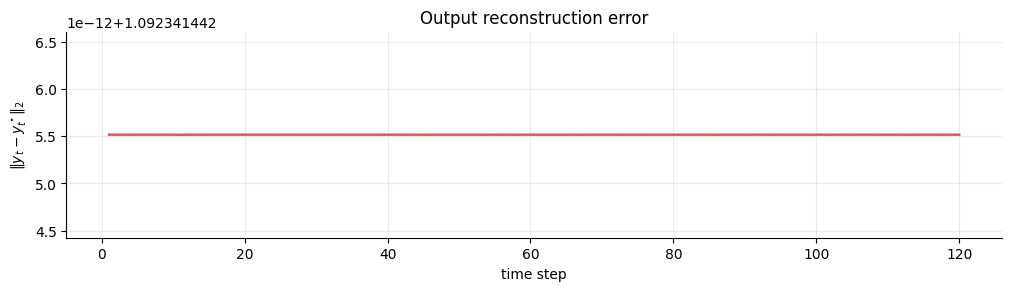

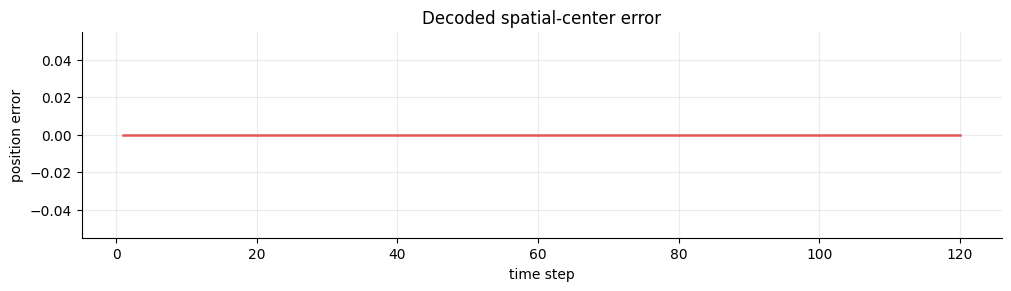

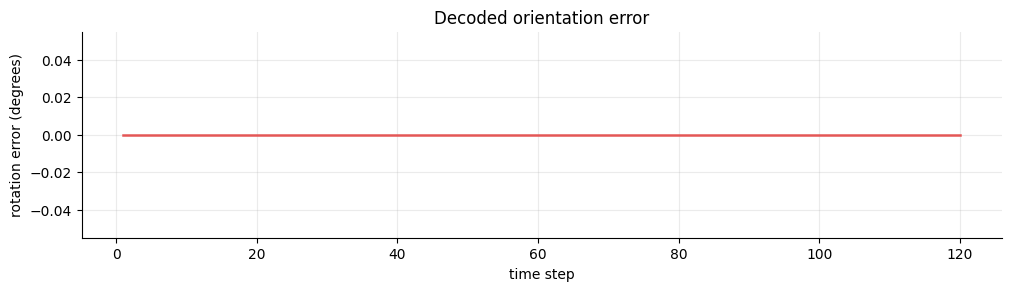

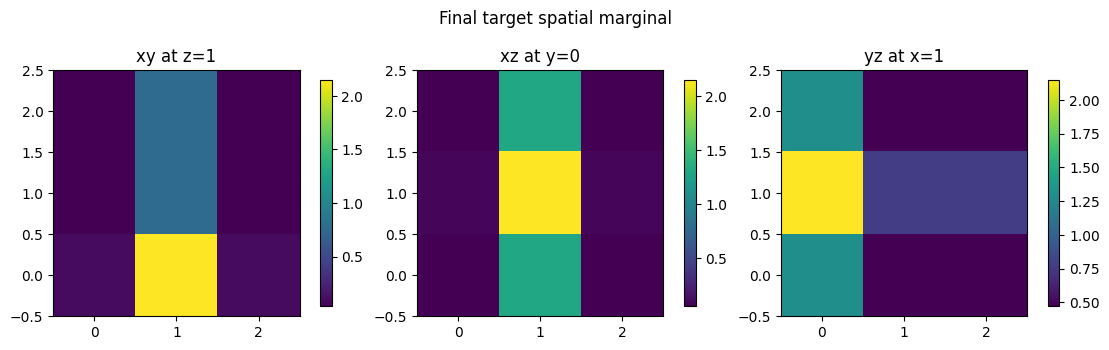

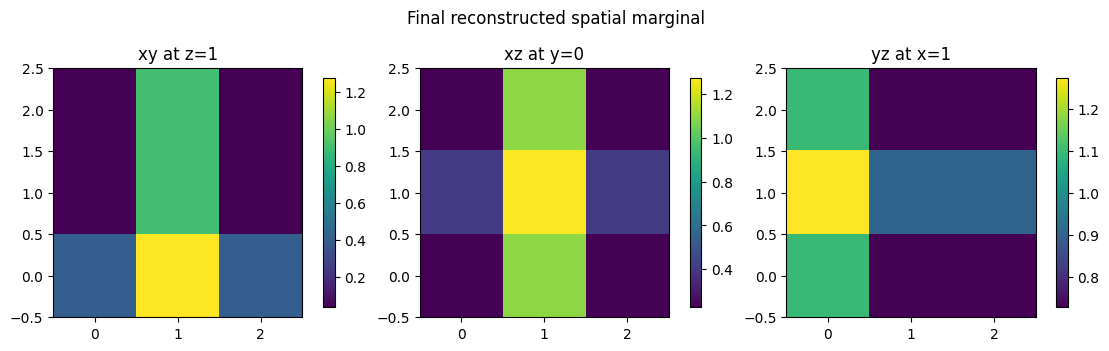

In [11]:
time = np.arange(1, num_long_steps + 1)
error_series = (
    (long_absolute_errors, r"$\|y_t-y_t^\star\|_2$", "Output reconstruction error"),
    (long["position_errors"], "position error", "Decoded spatial-center error"),
    (
        np.degrees(long["orientation_errors"]),
        "rotation error (degrees)",
        "Decoded orientation error",
    ),
)
for values, ylabel, title in error_series:
    figure, ax = plt.subplots(figsize=(10, 2.8), constrained_layout=True)
    ax.plot(time, values, color="#E45756", linewidth=1.8)
    ax.set(xlabel="time step", ylabel=ylabel, title=title)
    ax.grid(True, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.show()

final_target = spatial_marginal(G, long["rollout"]["true_outputs"][-1])
final_prediction = spatial_marginal(G, long["rollout"]["predicted_outputs"][-1])
plot_orthogonal_slices(
    final_target,
    center=tuple(long["target_poses"][-1, :3]),
    title="Final target spatial marginal",
)
plt.show()
plot_orthogonal_slices(
    final_prediction,
    center=tuple(long["predicted_poses"][-1, :3]),
    title="Final reconstructed spatial marginal",
)
plt.show()

## 7. Hidden-state tuning

These tuning curves are computed by transforming `x_allo` through every group element while holding the egocentric drive fixed at the identity. We show one unit from each distinct nontrivial selected irrep block, up to the visualization limit set in the cell below. One-dimensional blocks are omitted because they do not provide informative pose tuning.

A full tuning curve lives on 648 poses and cannot be displayed in one ordinary plot. We therefore use two complementary projections:

1. rotation slices are aligned to the allocentric frame and summed, producing one $3\times3\times3$ spatial tuning volume per neuron;
2. translation coordinates are summed, producing a representative-neuron by 24-orientation heatmap.

The spatial volumes are rendered as colored, activity-scaled lattice points. All panels use a shared raw-activation scale.

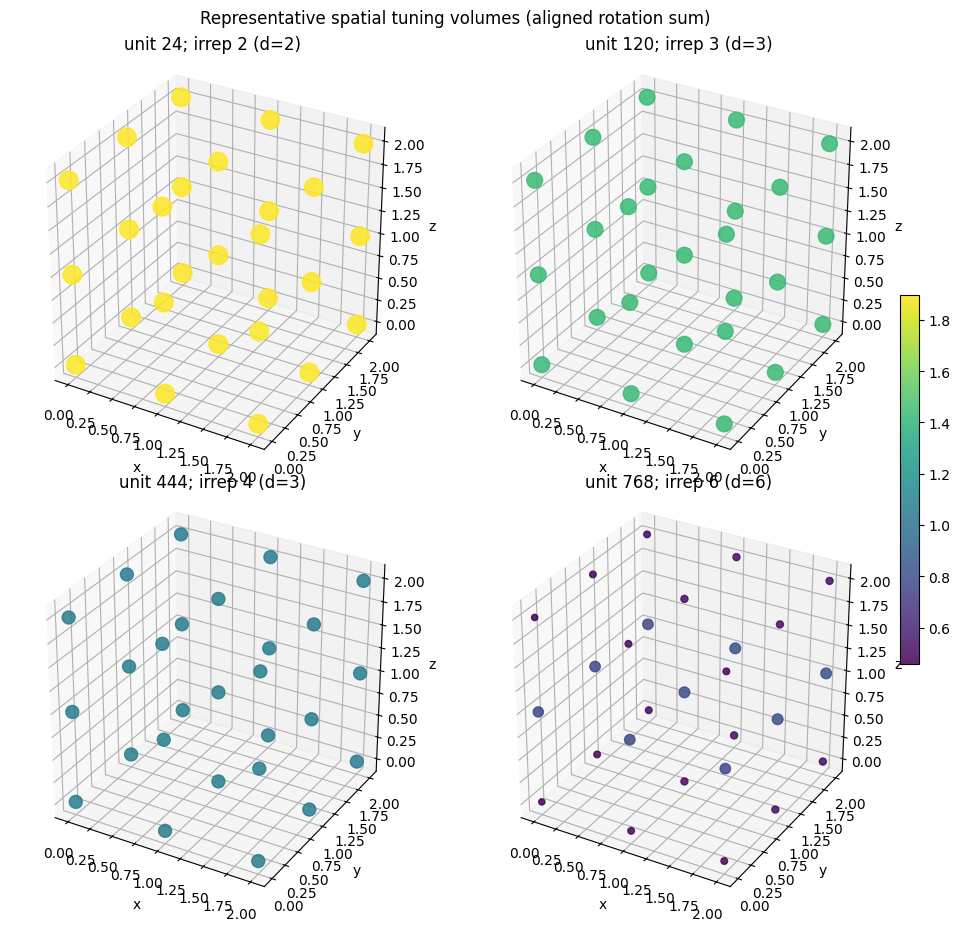

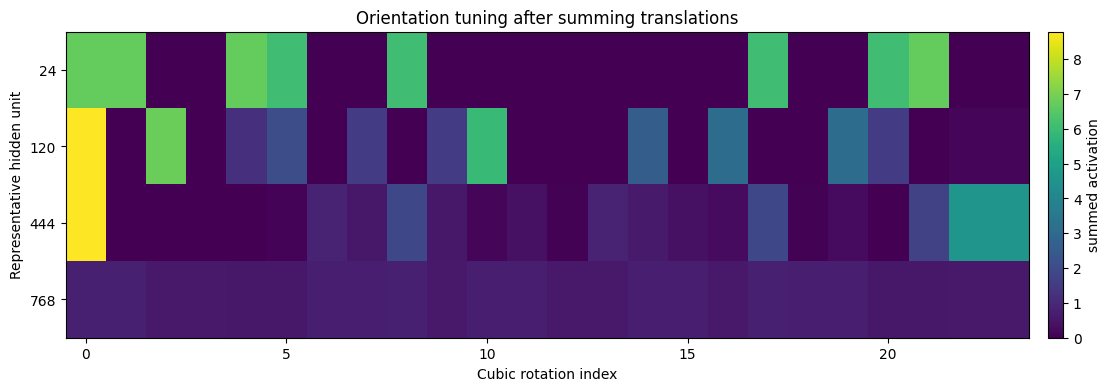

Selected tuning units
---------------------
24 {'irrep_index': 2, 'irrep_name': 'Zn3Oh_n3|orb0_size1_O_s2_d2', 'irrep_dim': 2, 'eps1': 1, 'eps2': 1, 'delta': 0, 'k0': 0, 'k1': 0, 'k2': 0}
120 {'irrep_index': 3, 'irrep_name': 'Zn3Oh_n3|orb0_size1_O_s3_d3', 'irrep_dim': 3, 'eps1': 1, 'eps2': 1, 'delta': 0, 'k0': 0, 'k1': 0, 'k2': 0}
444 {'irrep_index': 4, 'irrep_name': 'Zn3Oh_n3|orb0_size1_O_s4_d3', 'irrep_dim': 3, 'eps1': 1, 'eps2': 1, 'delta': 0, 'k0': 0, 'k1': 0, 'k2': 0}
768 {'irrep_index': 6, 'irrep_name': 'Zn3Oh_n3|orb1_size6_C4_s1_d6', 'irrep_dim': 6, 'eps1': 1, 'eps2': 1, 'delta': 0, 'k0': 0, 'k1': 0, 'k2': 0}


In [12]:
num_tuning_units_to_plot = 6

# These tuning curves sweep transformed allocentric inputs while holding the
# egocentric drive at the identity.
# Note: a trajectory-based analysis could instead sample movements from the
# data distribution and average each neuron's activity at a given group element
# across trajectories.
tuning_hidden = hidden_tuning_over_group(params, x_allo)
representatives = []
seen_irreps = set()
for unit, metadata in enumerate(params.metadata):
    irrep_index = metadata["irrep_index"]
    if metadata["irrep_dim"] == 1 or irrep_index in seen_irreps:
        continue
    representatives.append(unit)
    seen_irreps.add(irrep_index)
    if len(representatives) == num_tuning_units_to_plot:
        break

spatial_tuning = [
    spatial_marginal(G, tuning_hidden[:, unit], align_rotations=True)
    for unit in representatives
]
vmin = min(float(volume.min()) for volume in spatial_tuning)
vmax = max(float(volume.max()) for volume in spatial_tuning)

num_columns = 2 if len(representatives) <= 4 else 3
num_rows = int(np.ceil(len(representatives) / num_columns))
figure = plt.figure(
    figsize=(5 * num_columns, 4.5 * num_rows),
    constrained_layout=True,
)
artists = []
for panel, (unit, volume) in enumerate(zip(representatives, spatial_tuning), start=1):
    metadata = params.metadata[unit]
    ax = figure.add_subplot(num_rows, num_columns, panel, projection="3d")
    artists.append(
        plot_volume_scatter(
            volume,
            ax=ax,
            title=f"unit {unit}; irrep {metadata['irrep_index']} (d={metadata['irrep_dim']})",
            vmin=vmin,
            vmax=vmax,
        )
    )
figure.colorbar(artists[-1], ax=figure.axes, fraction=0.02, pad=0.02)
figure.suptitle("Representative spatial tuning volumes (aligned rotation sum)")
plt.show()

orientation_tuning = np.asarray(
    [orientation_marginal(G, tuning_hidden[:, unit]) for unit in representatives]
)
figure, ax = plt.subplots(figsize=(11, 3.8), constrained_layout=True)
image = ax.imshow(orientation_tuning, aspect="auto", cmap="viridis")
ax.set(
    xlabel="Cubic rotation index",
    ylabel="Representative hidden unit",
    title="Orientation tuning after summing translations",
)
ax.set_yticks(np.arange(len(representatives)), labels=representatives)
figure.colorbar(image, ax=ax, fraction=0.03, pad=0.02, label="summed activation")
plt.show()

print("Selected tuning units")
print("---------------------")
for unit in representatives:
    print(unit, params.metadata[unit])

In [13]:
power = G.power_spectrum(x_allo)
retained_fraction = power[params.selected_irrep_indices].sum() / power.sum()
all_width = sum(hidden_width(irrep) for irrep in all_irreps)

print(f"retained Fourier power: {retained_fraction:.2%}")
print(f"selected hidden width: {params.hidden_dim:,}")
print(f"all-irrep hidden width: {all_width:,}")
print(f"width reduction: {1 - params.hidden_dim / all_width:.2%}")

retained Fourier power: 48.60%
selected hidden width: 3,360
all-irrep hidden width: 71,040
width reduction: 95.27%


## 8. Module-restricted neural manifolds

We evaluate the module-restricted orbit separately for two probes:

1. **translation probe:** fix cubic orientation at the identity and vary all $3^3=27$ positions;
2. **orientation probe:** fix translation at the origin and vary all 24 cubic rotations.

For each retained nontrivial module, conjugate irreps are combined when needed. We verify the identity-update fixed-point residual before interpreting the hidden orbit as $\Phi$. UMAP is used only for visualization, while persistent homology is computed after PCA in neural space.

These results are necessarily exploratory. Twenty-seven spatial samples are far too sparse to establish the topology of a continuous three-torus, and the 24-element cubic rotation group is a finite noncommutative set—not a densely sampled copy of $SO(3)$ or a circle. The two probes are plotted separately precisely because their topology and interpretation differ.

identity-update fixed-point iteration: converged=True, iterations=1, max residual=5.721e-15


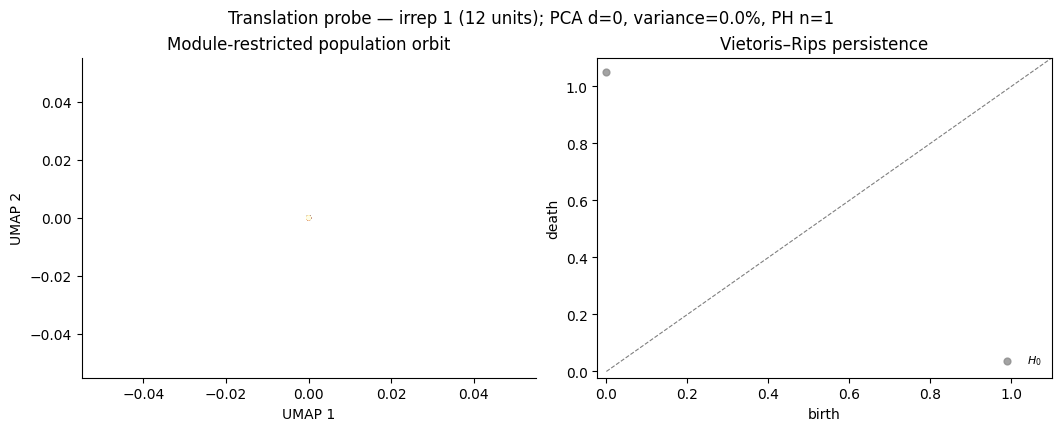

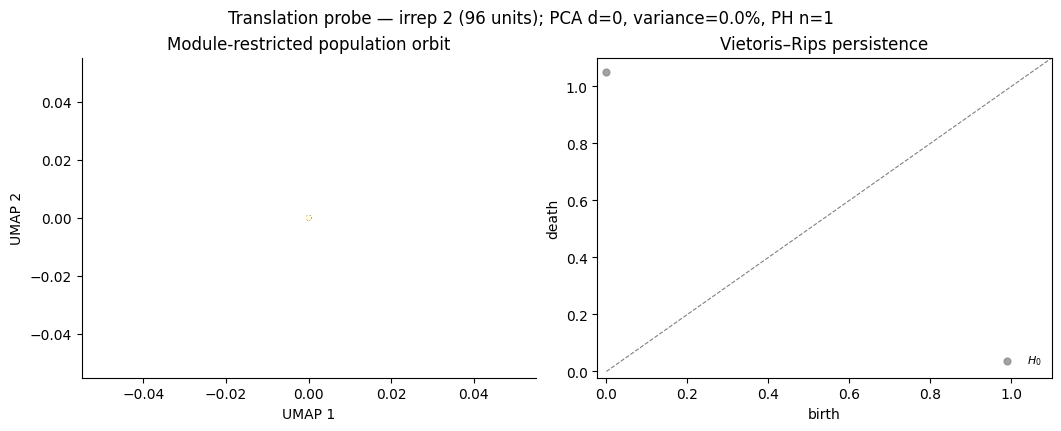

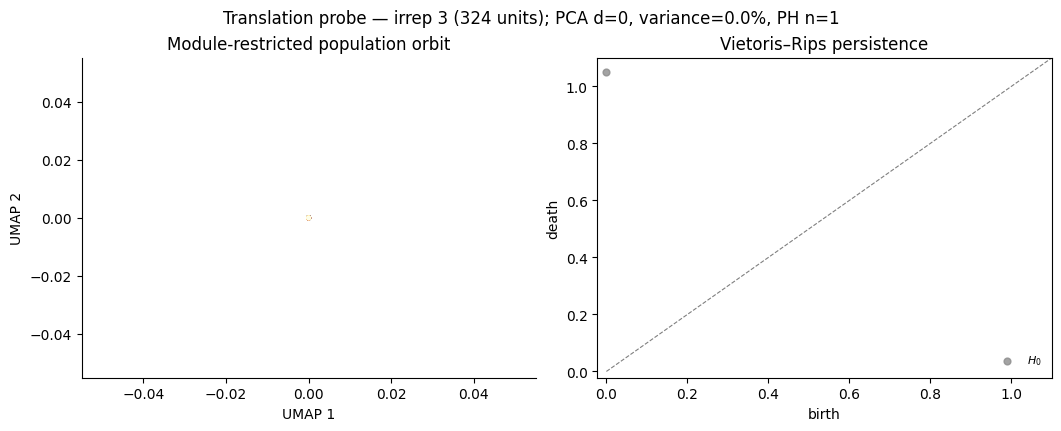

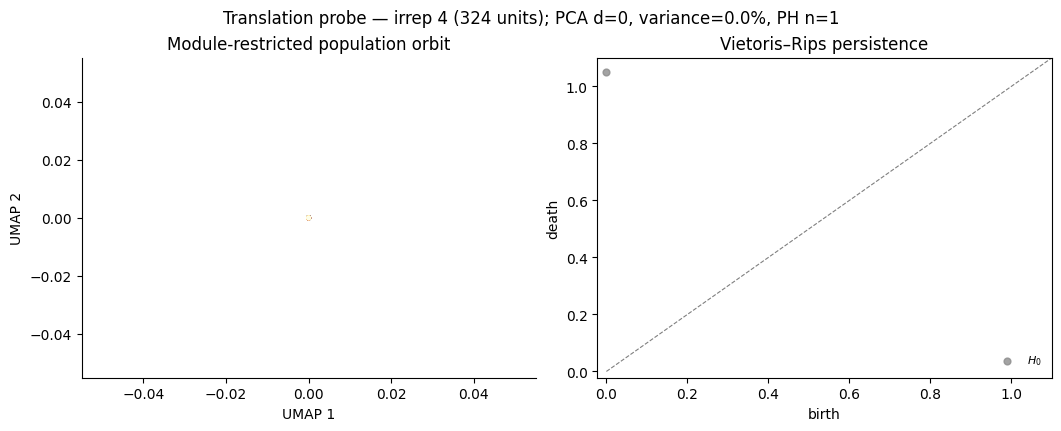

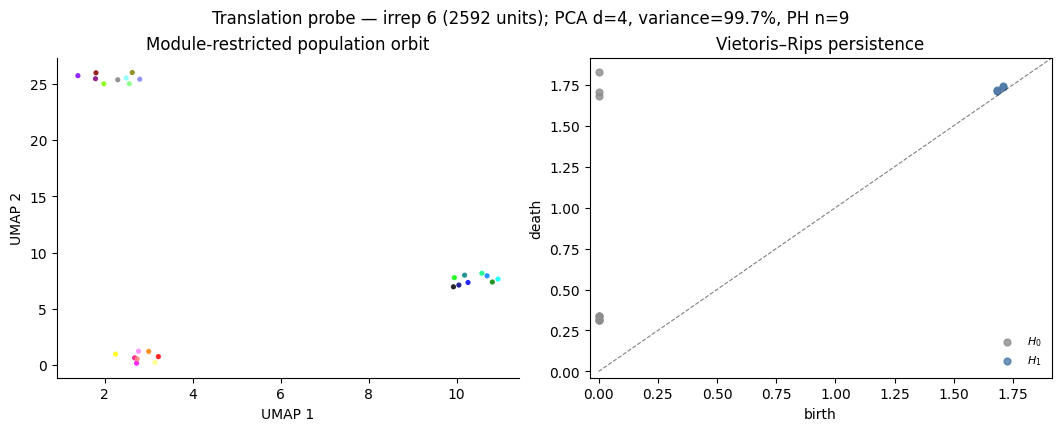

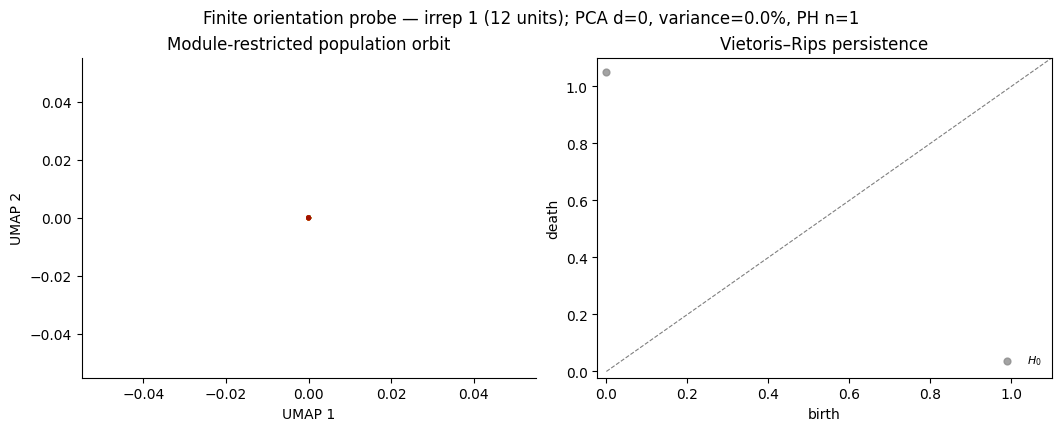

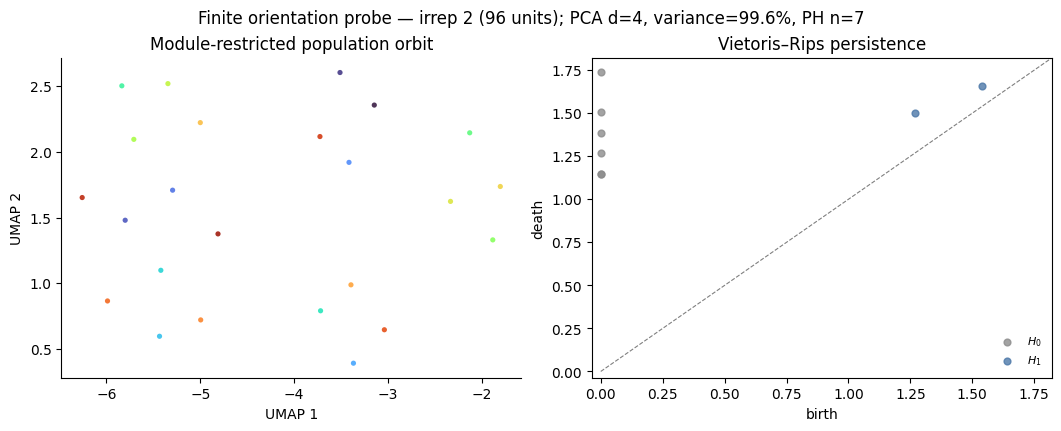

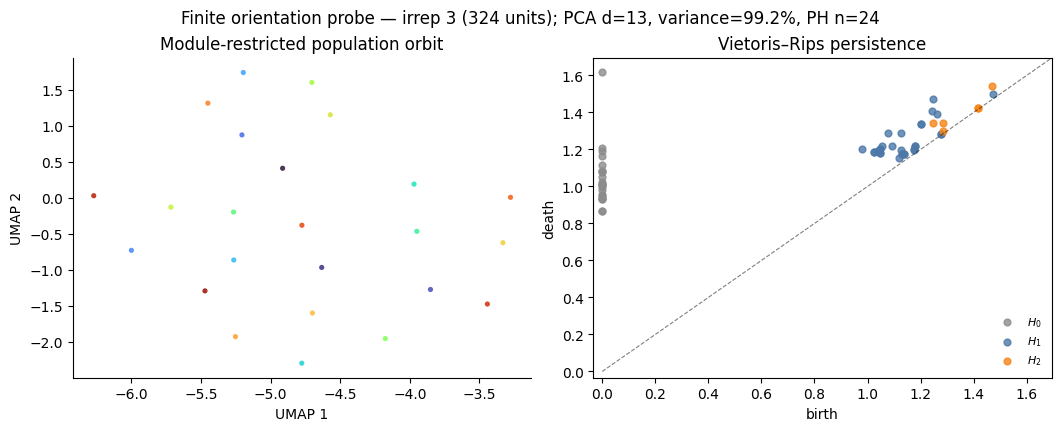

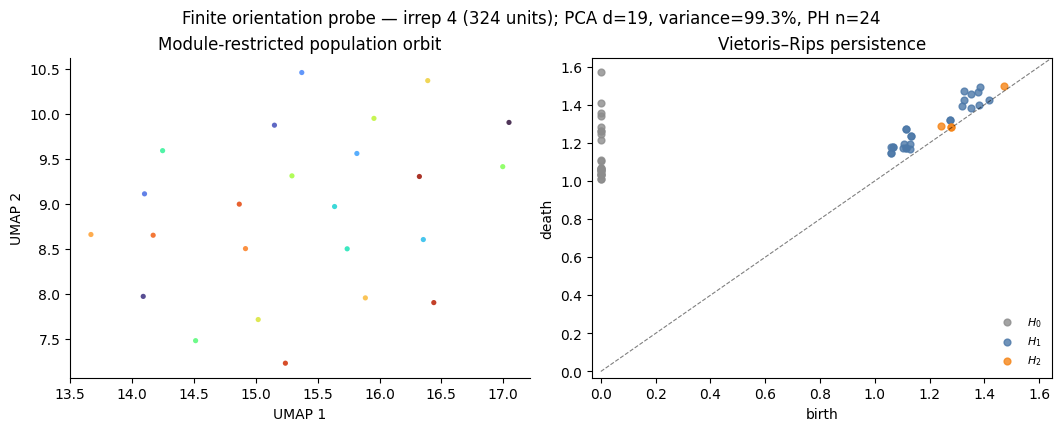

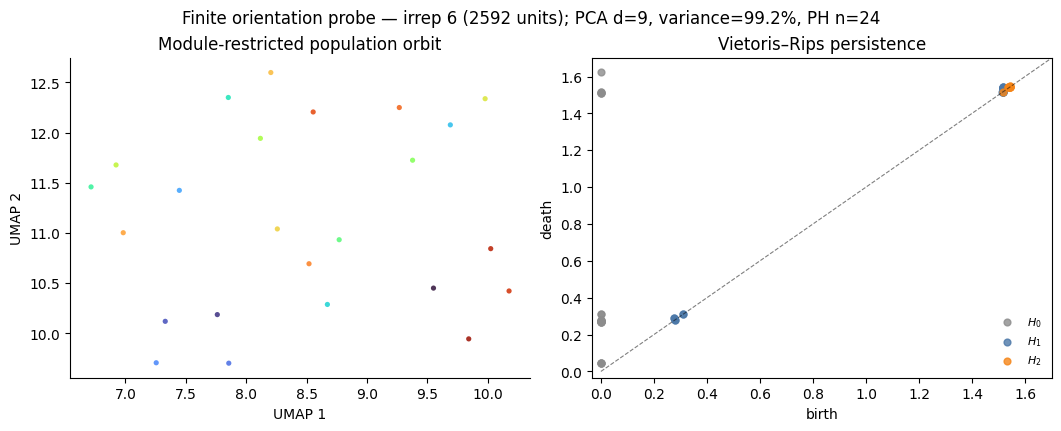

In [14]:
translation_elements = np.asarray(
    [
        G.encode(x, y, z, 0)
        for x in range(G.n)
        for y in range(G.n)
        for z in range(G.n)
    ]
)
translation_coordinates = np.asarray(
    [
        (x, y, z)
        for x in range(G.n)
        for y in range(G.n)
        for z in range(G.n)
    ]
)
orientation_elements = np.asarray(
    [G.encode(0, 0, 0, rotation) for rotation in range(G.num_rotations)]
)
translation_initial_hidden = tuning_hidden[translation_elements]
orientation_initial_hidden = tuning_hidden[orientation_elements]

fixed_probe_states = np.concatenate(
    (translation_initial_hidden, orientation_initial_hidden),
    axis=0,
)
fixed_probe = fixed_point_embedding(
    params,
    fixed_probe_states,
    tolerance=1e-10,
    max_iterations=20,
)
print(
    "identity-update fixed-point iteration: "
    f"converged={fixed_probe.converged}, "
    f"iterations={fixed_probe.iterations}, "
    f"max residual={fixed_probe.residuals.max():.3e}"
)
translation_fixed_hidden = fixed_probe.states[: len(translation_elements)]
orientation_fixed_hidden = fixed_probe.states[len(translation_elements) :]

translation_modules = build_module_orbits(params, translation_fixed_hidden)
orientation_modules = build_module_orbits(params, orientation_fixed_hidden)
translation_analyses = analyze_module_orbits(
    translation_modules,
    max_persistence_points=27,
    max_homology_dimension=2,
    random_state=13,
)
orientation_analyses = analyze_module_orbits(
    orientation_modules,
    max_persistence_points=24,
    max_homology_dimension=2,
    random_state=17,
)
translation_colors = coordinate_colors(
    translation_coordinates,
    (G.n, G.n, G.n),
)
orientation_colors = plt.get_cmap("turbo")(
    np.linspace(0, 1, G.num_rotations, endpoint=False)
)[:, :3]

for analysis in translation_analyses:
    plot_manifold_analysis(
        analysis,
        translation_colors,
        title=f"Translation probe — {analysis.module.label}",
    )
    plt.show()
for analysis in orientation_analyses:
    plot_manifold_analysis(
        analysis,
        orientation_colors,
        title=f"Finite orientation probe — {analysis.module.label}",
    )
    plt.show()

## 9. Conclusions and limitations

- The all-irrep $n=2$ construction verifies exact finite-group computation for translations, cubic rotations, and mixed noncommuting sequences.
- The $n=3$ experiment is deliberately approximate. Fourier retention, full signal error, position error, and orientation error quantify different consequences of truncation.
- Orientation must be observable in the encoding. A rotation-invariant signal cannot validate rotational state.
- The restored diagnostics parallel the SE(2) notebook: encodings, weight operators, rollouts, reconstruction errors, pose trajectories, tuning, and module-restricted manifold plots.
- Neural-manifold topology is probe-dependent. Translation-only and orientation-only orbits are analyzed separately and should not be conflated with the full pose orbit.
- The present 27-position and 24-orientation samples support exploratory geometry, not strong claims about continuous $\mathbb T^3$ or $SO(3)$ topology.
- UMAP is used only for display; persistent homology is computed in PCA-reduced neural space and remains sensitive to sampling and filtration scale.
- SE(3) visualization necessarily uses projections. Orthogonal slices, orientation bars, trajectories, tuning scatters, and manifold plots each discard part of the four-dimensional signal.
- Hidden width scales as $12\sum_\rho d_\rho^3$. Higher-dimensional induced irreps make cost-aware selection essential in three dimensions.
- Factored recurrent mixing removes the $O(H^2)$ storage cost of a dense `W_mix`, but `W_in` and `W_out` still scale as $O(H|G|)$.